# Multistatic Node Comparison

Purpose: compare deterministic multi-node CSI features, single-node behavior, and multistatic attention-weighted fusion for the Milestone 8 RuvSense advanced signal modules.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The cells are deterministic and do not require radio hardware or captured packets.

Fixture / simulated source: `make_multinode_fixture` creates four synthetic ESP32-style sensing nodes around a small room, three channel observations per node, phase offsets, cross-channel coherence, RSSI/packet-health metadata, a coherent body-reflection feature near a known target, and one intentionally low-quality node with an incoherent multipath artifact. Guarded imports probe future `ruview.ruvsense.multistatic`, `phase_align`, `multiband`, and `coherence` modules; local NumPy helpers keep the notebook runnable before those APIs land.

In [1]:
from dataclasses import dataclass
import math

import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError('Install the research extra with: uv sync --extra research') from exc

try:
    from ruview.ruvsense import multistatic as multistatic_api
except Exception as exc:
    multistatic_api = None
    MULTISTATIC_IMPORT_ERROR = exc
else:
    MULTISTATIC_IMPORT_ERROR = None

try:
    from ruview.ruvsense import phase_align as phase_align_api
except Exception as exc:
    phase_align_api = None
    PHASE_ALIGN_IMPORT_ERROR = exc
else:
    PHASE_ALIGN_IMPORT_ERROR = None

try:
    from ruview.ruvsense import multiband as multiband_api
except Exception as exc:
    multiband_api = None
    MULTIBAND_IMPORT_ERROR = exc
else:
    MULTIBAND_IMPORT_ERROR = None

try:
    from ruview.ruvsense import coherence as coherence_api
except Exception as exc:
    coherence_api = None
    COHERENCE_IMPORT_ERROR = exc
else:
    COHERENCE_IMPORT_ERROR = None

plt.rcParams.update({
    'figure.figsize': (11, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

API_IMPORT_STATUS = {
    'multistatic': 'available' if multistatic_api is not None else 'fallback',
    'phase_align': 'available' if phase_align_api is not None else 'fallback',
    'multiband': 'available' if multiband_api is not None else 'fallback',
    'coherence': 'available' if coherence_api is not None else 'fallback',
}


In [2]:
@dataclass(frozen=True)
class NodeSpec:
    node_id: str
    position_xy: tuple[float, float]
    z_m: float
    rssi_dbm: float
    packet_survival: float
    body_gain: float
    artifact_gain: float
    noise_scale: float
    phase_bias_rad: float
    target_bias_xy: tuple[float, float]
    artifact_xy: tuple[float, float]


def wrap_phase(values):
    return (np.asarray(values) + np.pi) % (2.0 * np.pi) - np.pi


def circular_mean(phases, weights=None, axis=0):
    phases = np.asarray(phases, dtype=float)
    if weights is None:
        sin_mean = np.mean(np.sin(phases), axis=axis)
        cos_mean = np.mean(np.cos(phases), axis=axis)
    else:
        weights = np.asarray(weights, dtype=float)
        if phases.ndim == 2 and weights.ndim == 1:
            weights = weights[:, None]
        sin_mean = np.sum(weights * np.sin(phases), axis=axis)
        cos_mean = np.sum(weights * np.cos(phases), axis=axis)
    return np.arctan2(sin_mean, cos_mean)


def cosine_similarity(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom < 1e-12:
        return 0.0
    return float(np.clip(np.dot(a, b) / denom, -1.0, 1.0))


def mapped_pearson(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if a.size == 0 or b.size == 0:
        return 0.0
    n = min(a.size, b.size)
    a = a[:n] - np.mean(a[:n])
    b = b[:n] - np.mean(b[:n])
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom < 1e-12:
        return 0.5
    corr = float(np.clip(np.dot(a, b) / denom, -1.0, 1.0))
    return 0.5 * (corr + 1.0)


def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    finite = np.isfinite(logits)
    if not np.any(finite):
        return np.ones_like(logits) / max(1, logits.size)
    shifted = logits.copy()
    shifted[~finite] = -np.inf
    shifted = shifted - np.max(shifted[finite])
    weights = np.exp(shifted)
    weights[~finite] = 0.0
    total = np.sum(weights)
    if total < 1e-12:
        return np.ones_like(logits) / max(1, logits.size)
    return weights / total


def phase_align_channels(amplitude, phase, static_fraction=0.35):
    amplitude = np.asarray(amplitude, dtype=float)
    phase = np.asarray(phase, dtype=float)
    n_channels, n_subcarriers = amplitude.shape
    n_static = max(5, int(math.ceil(static_fraction * n_subcarriers)))
    channel_variance = np.var(amplitude, axis=0)
    static_indices = np.argsort(channel_variance)[:n_static]

    offsets = np.zeros(n_channels, dtype=float)
    for channel_index in range(1, n_channels):
        delta = wrap_phase(phase[channel_index, static_indices] - phase[0, static_indices])
        offsets[channel_index] = circular_mean(delta, axis=0)

    corrected = wrap_phase(phase - offsets[:, None])
    return corrected, offsets, np.sort(static_indices)


def channel_coherence(amplitude):
    amplitude = np.asarray(amplitude, dtype=float)
    if amplitude.shape[0] < 2:
        return 1.0
    scores = []
    for left in range(amplitude.shape[0]):
        for right in range(left + 1, amplitude.shape[0]):
            scores.append(mapped_pearson(amplitude[left], amplitude[right]))
    return float(np.mean(scores))


def make_multinode_fixture(seed=8721, subcarriers=56):
    rng = np.random.default_rng(seed)
    room_xy = (6.0, 4.5)
    target_xy = np.array([3.35, 2.25])
    frequencies_mhz = np.array([2412, 2437, 2462])
    subcarrier_axis = np.linspace(-1.0, 1.0, subcarriers)
    nodes = [
        NodeSpec('northwest', (0.35, 0.45), 1.15, -43.0, 0.99, 1.04, 0.08, 0.010, 0.10, (-0.10, 0.08), (1.15, 3.75)),
        NodeSpec('northeast', (5.65, 0.40), 1.20, -48.0, 0.97, 0.94, 0.10, 0.014, -0.16, (0.12, 0.02), (4.95, 3.60)),
        NodeSpec('south', (3.00, 4.15), 1.05, -54.0, 0.94, 0.82, 0.14, 0.018, 0.24, (0.02, -0.12), (1.10, 0.70)),
        NodeSpec('west-lowq', (0.55, 2.95), 1.00, -79.0, 0.61, 0.18, 5.00, 0.085, -0.42, (-0.42, 0.34), (1.25, 3.45)),
    ]

    amplitudes = np.empty((len(nodes), len(frequencies_mhz), subcarriers), dtype=float)
    phases = np.empty_like(amplitudes)
    baselines = np.empty_like(amplitudes)

    coherent_body = np.exp(-((subcarrier_axis - 0.18) / 0.24) ** 2)
    coherent_body += 0.35 * np.exp(-((subcarrier_axis + 0.34) / 0.16) ** 2)
    coherent_body /= coherent_body.max()

    for node_index, node in enumerate(nodes):
        node_xy = np.array(node.position_xy)
        distance_to_target = np.linalg.norm(node_xy - target_xy)
        geometry_gain = 1.0 / (1.0 + 0.18 * distance_to_target)
        static_shape = (
            0.82
            + 0.09 * np.sin(np.pi * (subcarrier_axis + 1.0) * (1.0 + 0.1 * node_index))
            + 0.05 * np.cos(3.0 * np.pi * subcarrier_axis - 0.3 * node_index)
        )
        static_phase = 0.28 * np.sin(1.5 * np.pi * subcarrier_axis + node.phase_bias_rad)
        static_phase += 0.05 * node_index * subcarrier_axis

        for channel_index, frequency_mhz in enumerate(frequencies_mhz):
            if node.node_id == 'west-lowq':
                artifact_center = -0.72 + 0.34 * channel_index
            else:
                artifact_center = -0.58 + 0.08 * node_index
            artifact_shape = np.exp(-((subcarrier_axis - artifact_center) / 0.18) ** 2)
            channel_scale = 1.0 + 0.025 * (channel_index - 1)
            channel_ripple = 0.018 * np.cos(5.0 * np.pi * subcarrier_axis + channel_index)
            baseline = channel_scale * static_shape + channel_ripple
            baselines[node_index, channel_index] = baseline

            body = node.body_gain * geometry_gain * coherent_body
            artifact = node.artifact_gain * artifact_shape
            noise = rng.normal(0.0, node.noise_scale, subcarriers)
            amplitudes[node_index, channel_index] = baseline + body + artifact + noise

            lo_offset = np.array([0.00, 0.37, -0.29])[channel_index]
            body_phase = 0.08 * node.body_gain * np.sin(2.0 * np.pi * subcarrier_axis - 0.2)
            phase_noise = rng.normal(0.0, node.noise_scale * 1.8, subcarriers)
            phases[node_index, channel_index] = wrap_phase(static_phase + lo_offset + body_phase + phase_noise)

    return {
        'seed': seed,
        'room_xy': room_xy,
        'target_xy': target_xy,
        'frequencies_mhz': frequencies_mhz,
        'subcarrier_axis': subcarrier_axis,
        'nodes': nodes,
        'amplitude': amplitudes,
        'phase': phases,
        'baseline_amplitude': baselines,
        'timestamp_us': np.array([1_700_000, 1_701_100, 1_701_650, 1_703_900], dtype=np.uint64),
    }


def build_multiband_node_frames(fixture):
    frames = []
    for node_index, node in enumerate(fixture['nodes']):
        amplitude = fixture['amplitude'][node_index]
        phase = fixture['phase'][node_index]
        aligned_phase, phase_offsets, static_indices = phase_align_channels(amplitude, phase)
        mean_amplitude = amplitude.mean(axis=0)
        mean_baseline = fixture['baseline_amplitude'][node_index].mean(axis=0)
        mean_phase = circular_mean(aligned_phase, axis=0)
        motion_feature = mean_amplitude - mean_baseline
        frames.append({
            'spec': node,
            'timestamp_us': int(fixture['timestamp_us'][node_index]),
            'mean_amplitude': mean_amplitude,
            'mean_phase': mean_phase,
            'motion_feature': motion_feature,
            'channel_coherence': channel_coherence(amplitude - fixture['baseline_amplitude'][node_index]),
            'phase_offsets_rad': phase_offsets,
            'static_indices': static_indices,
        })
    return frames


def score_nodes(frames):
    motion_matrix = np.vstack([frame['motion_feature'] for frame in frames])
    consensus = np.median(motion_matrix, axis=0)
    summaries = []
    for frame in frames:
        spec = frame['spec']
        rssi_score = np.clip((spec.rssi_dbm + 90.0) / 55.0, 0.0, 1.0)
        packet_score = np.clip(spec.packet_survival, 0.0, 1.0)
        consensus_score = 0.5 * (cosine_similarity(frame['motion_feature'], consensus) + 1.0)
        roughness = np.std(np.diff(frame['motion_feature']))
        stability_score = 1.0 / (1.0 + 32.0 * roughness)
        quality = (
            0.23 * rssi_score
            + 0.20 * packet_score
            + 0.25 * frame['channel_coherence']
            + 0.22 * consensus_score
            + 0.10 * stability_score
        )
        summaries.append({
            'rssi_score': float(rssi_score),
            'packet_score': float(packet_score),
            'consensus_score': float(consensus_score),
            'stability_score': float(stability_score),
            'channel_coherence': float(frame['channel_coherence']),
            'quality': float(np.clip(quality, 0.0, 1.0)),
        })
    return summaries


def attention_weights(frames, summaries=None, temperature=0.30, quality_gate=None):
    features = np.vstack([frame['motion_feature'] for frame in frames])
    if summaries is not None and quality_gate is not None:
        quality = np.array([summary['quality'] for summary in summaries])
        mask = quality >= quality_gate
        consensus = np.median(features[mask], axis=0) if np.any(mask) else np.median(features, axis=0)
    else:
        quality = None
        mask = np.ones(len(frames), dtype=bool)
        consensus = np.mean(features, axis=0)

    similarities = np.array([cosine_similarity(feature, consensus) for feature in features])
    logits = similarities / max(temperature, 1e-6)

    if summaries is not None:
        quality = np.array([summary['quality'] for summary in summaries])
        logits = logits + np.log(np.clip(quality, 1e-3, 1.0))
    if quality_gate is not None:
        logits = logits.copy()
        logits[~mask] = -np.inf

    return softmax(logits), similarities


def fuse_node_vectors(frames, weights):
    weights = np.asarray(weights, dtype=float)
    amplitudes = np.vstack([frame['mean_amplitude'] for frame in frames])
    phases = np.vstack([frame['mean_phase'] for frame in frames])
    features = np.vstack([frame['motion_feature'] for frame in frames])
    return {
        'mean_amplitude': np.sum(weights[:, None] * amplitudes, axis=0),
        'mean_phase': circular_mean(phases, weights=weights, axis=0),
        'motion_feature': np.sum(weights[:, None] * features, axis=0),
    }


def normalized_entropy(weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights[weights > 1e-12]
    if weights.size <= 1:
        return 1.0
    return float(np.clip(-np.sum(weights * np.log(weights)) / np.log(weights.size), 0.0, 1.0))


def gaussian_field(xx, yy, center_xy, sigma_xy):
    cx, cy = center_xy
    sx, sy = sigma_xy
    return np.exp(-0.5 * (((xx - cx) / sx) ** 2 + ((yy - cy) / sy) ** 2))


def make_node_fields(fixture, summaries, nx=96, ny=72):
    room_x, room_y = fixture['room_xy']
    x = np.linspace(0.0, room_x, nx)
    y = np.linspace(0.0, room_y, ny)
    xx, yy = np.meshgrid(x, y)
    target_xy = fixture['target_xy']
    fields = []

    for node, summary in zip(fixture['nodes'], summaries, strict=True):
        quality = summary['quality']
        bias = np.array(node.target_bias_xy)
        target_center = target_xy + bias
        target_sigma = 0.34 + 0.45 * (1.0 - quality)
        target_field = node.body_gain * gaussian_field(xx, yy, target_center, (target_sigma, target_sigma * 0.88))
        artifact_sigma = 0.34 + 0.18 * node.artifact_gain
        artifact_field = node.artifact_gain * gaussian_field(xx, yy, node.artifact_xy, (artifact_sigma, artifact_sigma))
        node_field = target_field + artifact_field
        fields.append(node_field)

    return x, y, np.stack(fields, axis=0)


def weighted_field(fields, weights):
    field = np.sum(np.asarray(weights)[:, None, None] * fields, axis=0)
    return field / max(float(field.max()), 1e-12)


def field_peak(field, x, y):
    iy, ix = np.unravel_index(np.argmax(field), field.shape)
    return np.array([x[ix], y[iy]])


def format_node_table(frames, summaries, single_weights, naive_weights, quality_weights):
    header = 'node          rssi  pkt  ch_coh  consensus  quality  single  naive  quality_fused'
    lines = [header, '-' * len(header)]
    for frame, summary, single_w, naive_w, quality_w in zip(
        frames, summaries, single_weights, naive_weights, quality_weights, strict=True
    ):
        spec = frame['spec']
        lines.append(
            f"{spec.node_id:<12} {spec.rssi_dbm:>5.0f} "
            f"{summary['packet_score']:>4.2f} {summary['channel_coherence']:>7.2f} "
            f"{summary['consensus_score']:>9.2f} {summary['quality']:>8.2f} "
            f"{single_w:>7.2f} {naive_w:>6.2f} {quality_w:>14.2f}"
        )
    return '\n'.join(lines)


In [3]:
fixture = make_multinode_fixture()
frames = build_multiband_node_frames(fixture)
summaries = score_nodes(frames)
QUALITY_GATE = 0.70

single_index = int(np.argmax([summary['quality'] for summary in summaries]))
single_weights = np.zeros(len(frames), dtype=float)
single_weights[single_index] = 1.0

naive_weights, naive_similarity = attention_weights(frames, summaries=None, temperature=0.30)
quality_weights, quality_similarity = attention_weights(
    frames,
    summaries=summaries,
    temperature=0.30,
    quality_gate=QUALITY_GATE,
)

single_fused = fuse_node_vectors(frames, single_weights)
naive_fused = fuse_node_vectors(frames, naive_weights)
quality_fused = fuse_node_vectors(frames, quality_weights)

x_grid, y_grid, node_fields = make_node_fields(fixture, summaries)
single_field = weighted_field(node_fields, single_weights)
naive_field = weighted_field(node_fields, naive_weights)
quality_field = weighted_field(node_fields, quality_weights)

target_xy = fixture['target_xy']
field_outputs = {
    'single best node': single_field,
    'naive all-node fusion': naive_field,
    'quality-gated fusion': quality_field,
}
field_errors_m = {
    label: float(np.linalg.norm(field_peak(field, x_grid, y_grid) - target_xy))
    for label, field in field_outputs.items()
}

print('Guarded RuvSense import status:', API_IMPORT_STATUS)
print(format_node_table(frames, summaries, single_weights, naive_weights, quality_weights))
print('\nWeight entropy:')
print(f"  naive all-node fusion: {normalized_entropy(naive_weights):.2f}")
print(f"  quality-gated fusion: {normalized_entropy(quality_weights):.2f}")
print('\nLocalization peak error against synthetic target:')
for label, error_m in field_errors_m.items():
    print(f"  {label}: {error_m:.2f} m")


Guarded RuvSense import status: {'multistatic': 'available', 'phase_align': 'available', 'multiband': 'available', 'coherence': 'available'}
node          rssi  pkt  ch_coh  consensus  quality  single  naive  quality_fused
---------------------------------------------------------------------------------
northwest      -43 0.99    1.00      1.00     0.91    1.00   0.22           0.34
northeast      -48 0.97    1.00      1.00     0.88    0.00   0.23           0.34
south          -54 0.94    1.00      1.00     0.85    0.00   0.24           0.32
west-lowq      -79 0.61    0.43      0.80     0.47    0.00   0.30           0.00

Weight entropy:
  naive all-node fusion: 0.99
  quality-gated fusion: 1.00

Localization peak error against synthetic target:
  single best node: 0.16 m
  naive all-node fusion: 2.43 m
  quality-gated fusion: 0.03 m


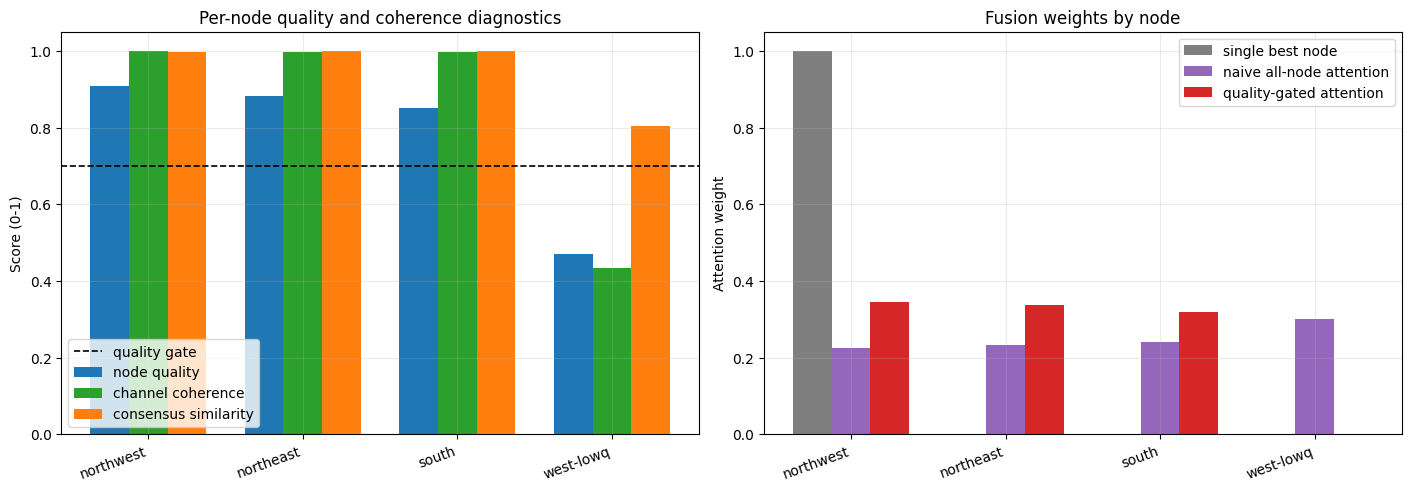

In [4]:
node_labels = [frame['spec'].node_id for frame in frames]
quality_scores = np.array([summary['quality'] for summary in summaries])
channel_scores = np.array([summary['channel_coherence'] for summary in summaries])
consensus_scores = np.array([summary['consensus_score'] for summary in summaries])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
x_positions = np.arange(len(node_labels))
bar_width = 0.25

axes[0].bar(x_positions - bar_width, quality_scores, width=bar_width, label='node quality', color='tab:blue')
axes[0].bar(x_positions, channel_scores, width=bar_width, label='channel coherence', color='tab:green')
axes[0].bar(x_positions + bar_width, consensus_scores, width=bar_width, label='consensus similarity', color='tab:orange')
axes[0].axhline(QUALITY_GATE, color='black', linestyle='--', linewidth=1.2, label='quality gate')
axes[0].set_title('Per-node quality and coherence diagnostics')
axes[0].set_ylabel('Score (0-1)')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(node_labels, rotation=20, ha='right')
axes[0].set_ylim(0.0, 1.05)
axes[0].legend(loc='lower left')

axes[1].bar(x_positions - bar_width, single_weights, width=bar_width, label='single best node', color='tab:gray')
axes[1].bar(x_positions, naive_weights, width=bar_width, label='naive all-node attention', color='tab:purple')
axes[1].bar(x_positions + bar_width, quality_weights, width=bar_width, label='quality-gated attention', color='tab:red')
axes[1].set_title('Fusion weights by node')
axes[1].set_ylabel('Attention weight')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(node_labels, rotation=20, ha='right')
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(loc='upper right')

plt.show()


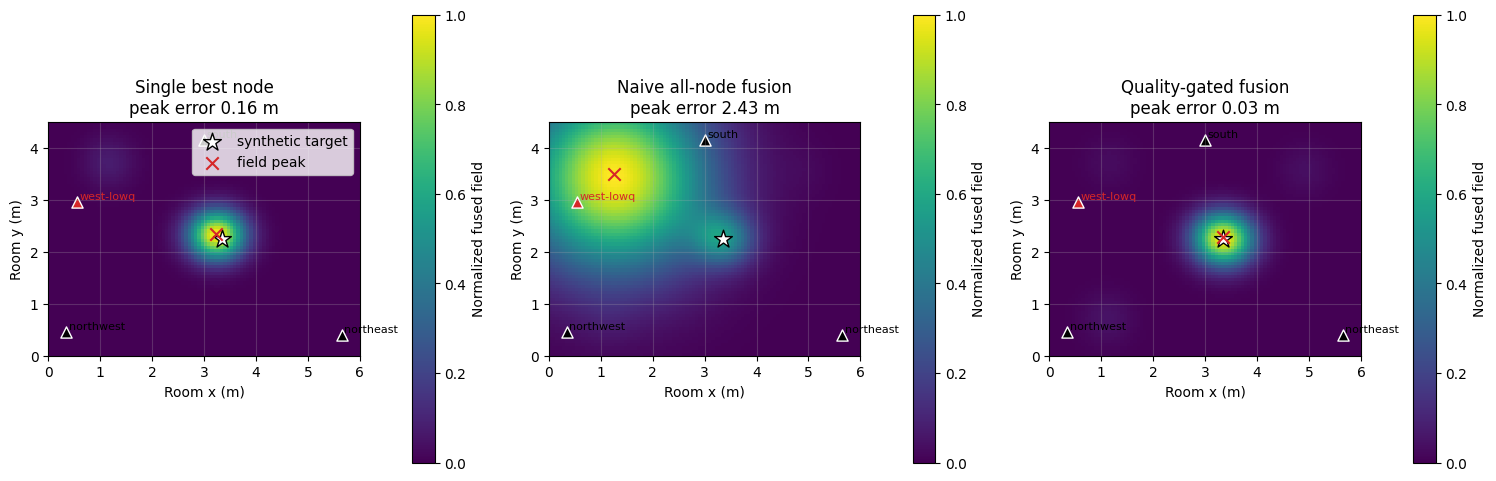

In [5]:
extent = [0.0, fixture['room_xy'][0], 0.0, fixture['room_xy'][1]]
plots = [
    ('Single best node', single_field, field_errors_m['single best node']),
    ('Naive all-node fusion', naive_field, field_errors_m['naive all-node fusion']),
    ('Quality-gated fusion', quality_field, field_errors_m['quality-gated fusion']),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for axis, (title, field, error_m) in zip(axes, plots, strict=True):
    image = axis.imshow(field, origin='lower', extent=extent, cmap='viridis', vmin=0.0, vmax=1.0)
    axis.scatter(target_xy[0], target_xy[1], marker='*', s=180, c='white', edgecolors='black', label='synthetic target')
    for frame, summary in zip(frames, summaries, strict=True):
        node = frame['spec']
        color = 'tab:red' if summary['quality'] < QUALITY_GATE else 'black'
        axis.scatter(node.position_xy[0], node.position_xy[1], marker='^', s=65, c=color, edgecolors='white')
        axis.text(node.position_xy[0] + 0.05, node.position_xy[1] + 0.05, node.node_id, color=color, fontsize=8)
    peak_xy = field_peak(field, x_grid, y_grid)
    axis.scatter(peak_xy[0], peak_xy[1], marker='x', s=80, c='tab:red', label='field peak')
    axis.set_title(f'{title}\npeak error {error_m:.2f} m')
    axis.set_xlabel('Room x (m)')
    axis.set_ylabel('Room y (m)')
    axis.set_xlim(0.0, fixture['room_xy'][0])
    axis.set_ylim(0.0, fixture['room_xy'][1])
    fig.colorbar(image, ax=axis, label='Normalized fused field')

axes[0].legend(loc='upper right')
plt.show()


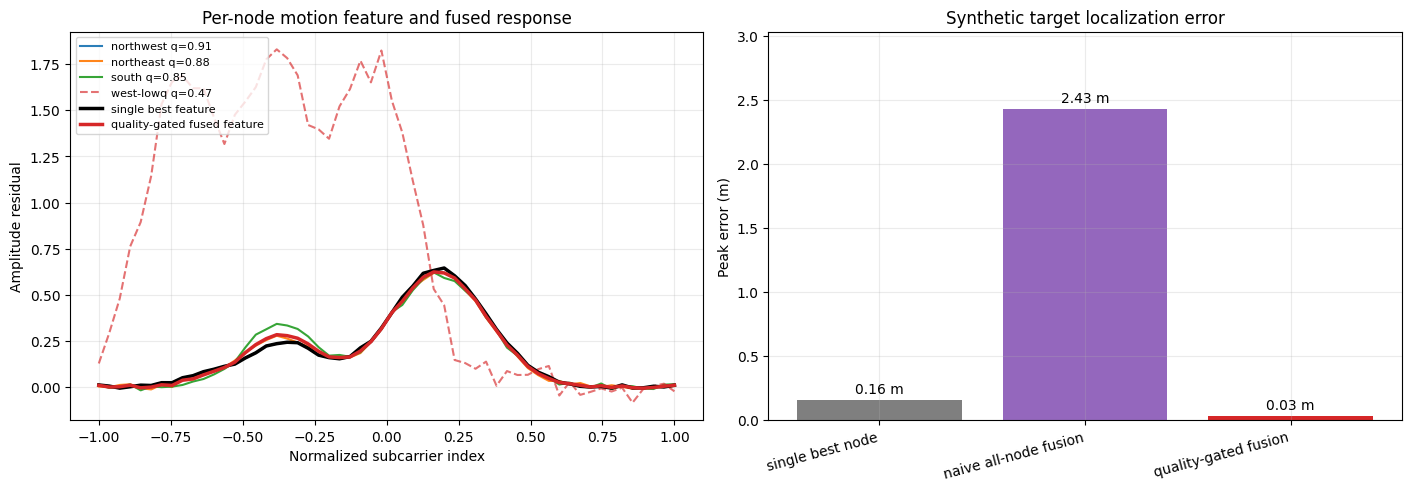

In [6]:
subcarrier_axis = fixture['subcarrier_axis']
low_quality_mask = quality_scores < QUALITY_GATE

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for frame, summary in zip(frames, summaries, strict=True):
    style = '--' if summary['quality'] < QUALITY_GATE else '-'
    alpha = 0.95 if summary['quality'] >= QUALITY_GATE else 0.65
    axes[0].plot(
        subcarrier_axis,
        frame['motion_feature'],
        linestyle=style,
        alpha=alpha,
        label=f"{frame['spec'].node_id} q={summary['quality']:.2f}",
    )
axes[0].plot(subcarrier_axis, single_fused['motion_feature'], color='black', linewidth=2.5, label='single best feature')
axes[0].plot(subcarrier_axis, quality_fused['motion_feature'], color='tab:red', linewidth=2.5, label='quality-gated fused feature')
axes[0].set_title('Per-node motion feature and fused response')
axes[0].set_xlabel('Normalized subcarrier index')
axes[0].set_ylabel('Amplitude residual')
axes[0].legend(loc='upper left', fontsize=8)

error_labels = list(field_errors_m.keys())
error_values = [field_errors_m[label] for label in error_labels]
axes[1].bar(error_labels, error_values, color=['tab:gray', 'tab:purple', 'tab:red'])
axes[1].set_title('Synthetic target localization error')
axes[1].set_ylabel('Peak error (m)')
axes[1].set_xticks(np.arange(len(error_labels)))
axes[1].set_xticklabels(error_labels, rotation=15, ha='right')
axes[1].set_ylim(0.0, max(error_values) * 1.25)
for index, value in enumerate(error_values):
    axes[1].text(index, value + 0.03, f'{value:.2f} m', ha='center', va='bottom')

plt.show()


Expected interpretation: the three healthy nodes should show high channel coherence and similar body-reflection features, while `west-lowq` should fall below the quality gate because of weak RSSI, lower packet survival, rougher residuals, and poor consensus agreement. Naive all-node attention can allocate some weight to the artifact node, but the quality-gated fusion should suppress it, keep balanced weight across the coherent nodes, and move the fused room-field peak closer to the synthetic target than the low-quality-contaminated fusion.

Limitations: this is a deterministic visual fixture, not a validated RF propagation model. The local fallbacks approximate the Rust reference ideas with readable NumPy helpers instead of the future Python `ruview.ruvsense` APIs, RuVector attention/min-cut machinery, CIR dominant-tap gating, real ESP32 timing, calibrated antenna geometry, packet loss bursts, or hardware phase sanitization. Treat thresholds and localization errors as notebook diagnostics only.